# Notebook 02 — Exploratory Data Analysis

**Author:** Zun Ding Han

## Objective

This notebook explores the AI4I 2020 Predictive Maintenance dataset to identify patterns associated with machine failure.

The analysis focuses on:

- Machine failure frequency
- Product type distribution
- Sensor variable distributions
- Relationships between sensor measurements and machine failure
- Correlations between numerical variables
- Individual failure modes
- Potential outliers and unusual operating conditions

The findings from this analysis will guide feature engineering and model development in later stages of the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/ai4i2020.csv")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
sensor_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

target = "Machine failure"

failure_columns = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

## 1. Machine Failure Distribution

Before modelling, it is important to understand how frequently machine failures occur

A strong imbalance between normal and failed observations can influence model selection and evaluation

In [3]:
failure_counts = df[target].value_counts().sort_index()
failure_percentages = df[target].value_counts(normalize=True).sort_index() * 100

failure_summary = pd.DataFrame({
    "Count": failure_counts,
    "Percentage": failure_percentages
})

failure_summary.index = ["No Failure", "Failure"]

failure_summary

,Count,Percentage
No Failure,9661,96.61
Failure,339,3.39


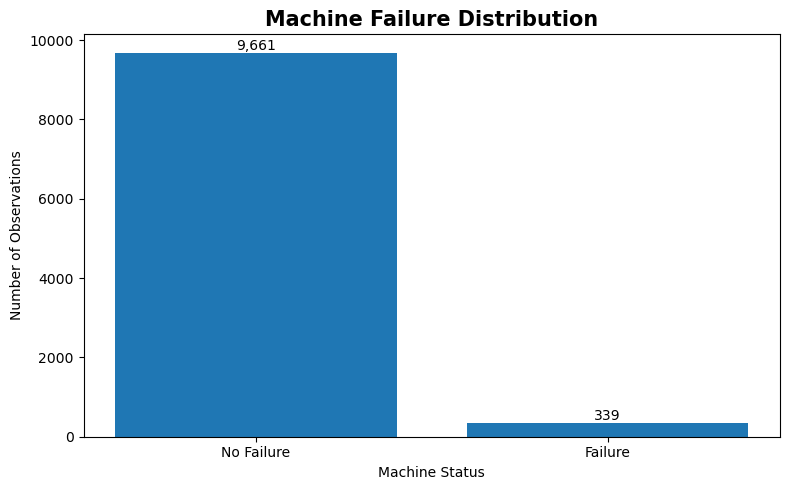

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    ["No Failure", "Failure"],
    failure_counts.values
)

ax.set_title("Machine Failure Distribution", fontsize=15, fontweight="bold")
ax.set_xlabel("Machine Status")
ax.set_ylabel("Number of Observations")

for bar, count in zip(bars, failure_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("../images/machine_failure_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Product Type Distribution

The `Type` variable represents the product quality category:

- L — Low
- M — Medium
- H — High

The distribution is examined to determine whether the dataset contains substantially different numbers of observations across product types

In [5]:
type_counts = df["Type"].value_counts()

type_counts

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

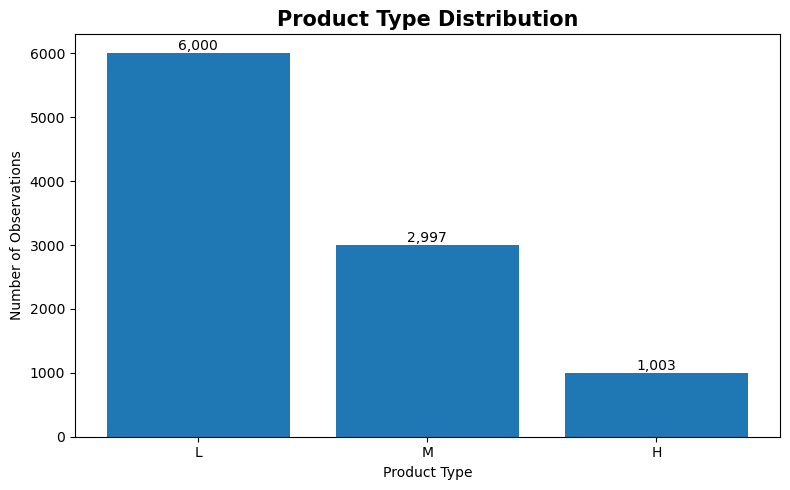

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(type_counts.index, type_counts.values)

ax.set_title("Product Type Distribution", fontsize=15, fontweight="bold")
ax.set_xlabel("Product Type")
ax.set_ylabel("Number of Observations")

for bar, count in zip(bars, type_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("../images/product_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Failure Rate by Product Type

Rather than only comparing the number of machines in each product category, the failure rate within each category is calculated

This helps determine whether machine failure appears to be associated with product type

In [7]:
failure_by_type = (
    df.groupby("Type")[target]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "Observations",
        "sum": "Failures",
        "mean": "Failure Rate"
    })
)

failure_by_type["Failure Rate (%)"] = (
    failure_by_type["Failure Rate"] * 100
)

failure_by_type


,Observations,Failures,Failure Rate,Failure Rate (%)
Type,,,,
H,1003,21,0.020937,2.093719
L,6000,235,0.039167,3.916667
M,2997,83,0.027694,2.769436


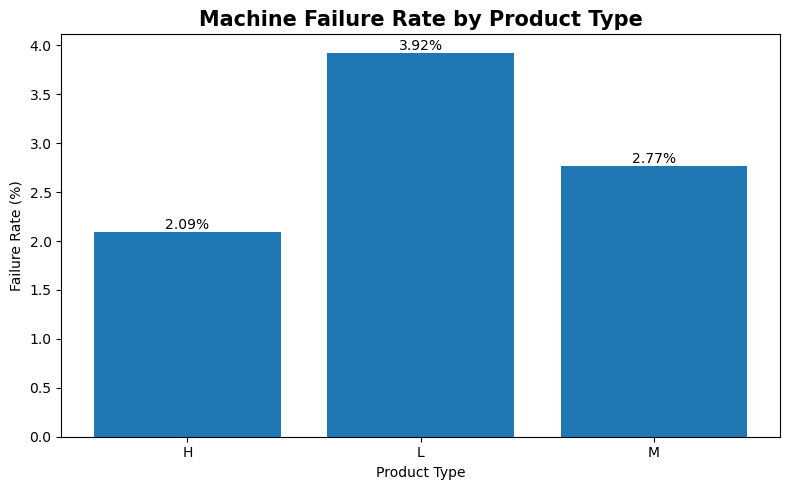

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    failure_by_type.index,
    failure_by_type["Failure Rate (%)"]
)

ax.set_title("Machine Failure Rate by Product Type", fontsize=15, fontweight="bold")
ax.set_xlabel("Product Type")
ax.set_ylabel("Failure Rate (%)")

for bar, value in zip(bars, failure_by_type["Failure Rate (%)"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("../images/failure_rate_by_product_type.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Sensor Variable Distributions

The distributions of the main operational variables are examined to understand their ranges, central tendencies and potential unusual observations

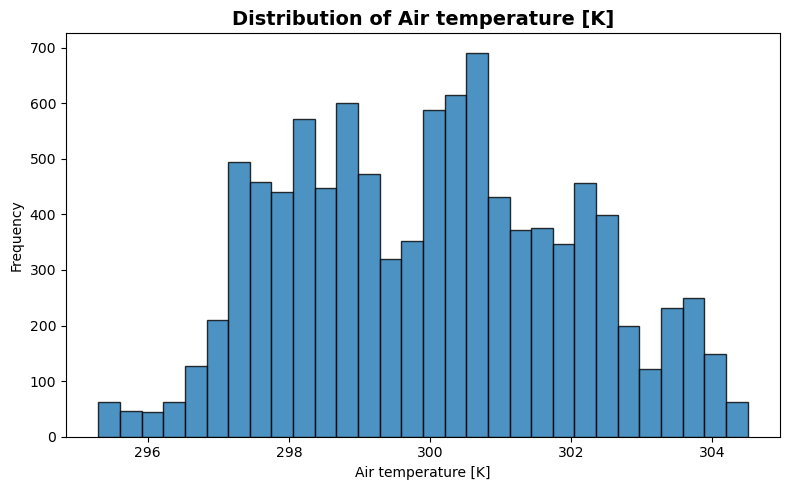

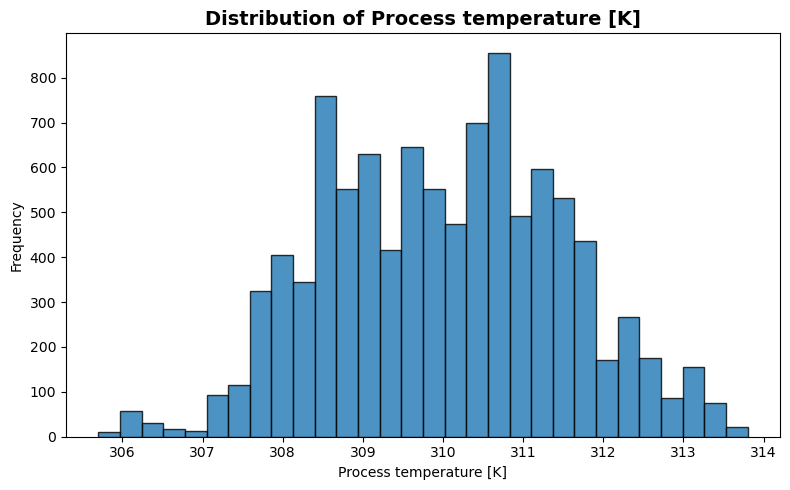

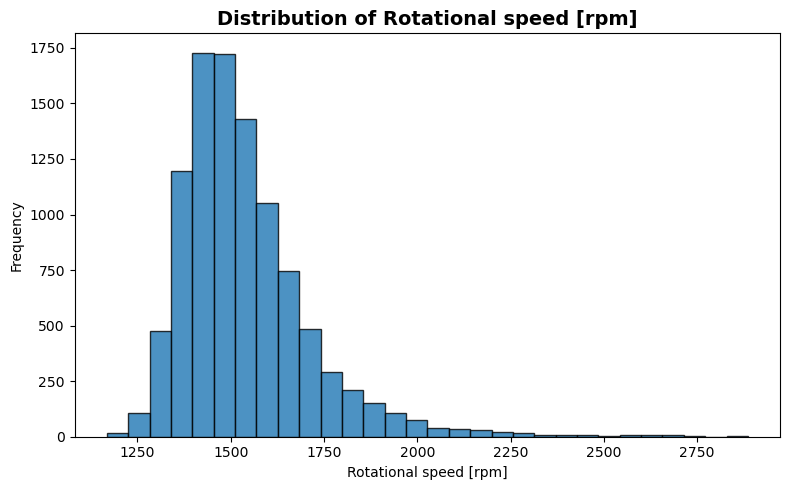

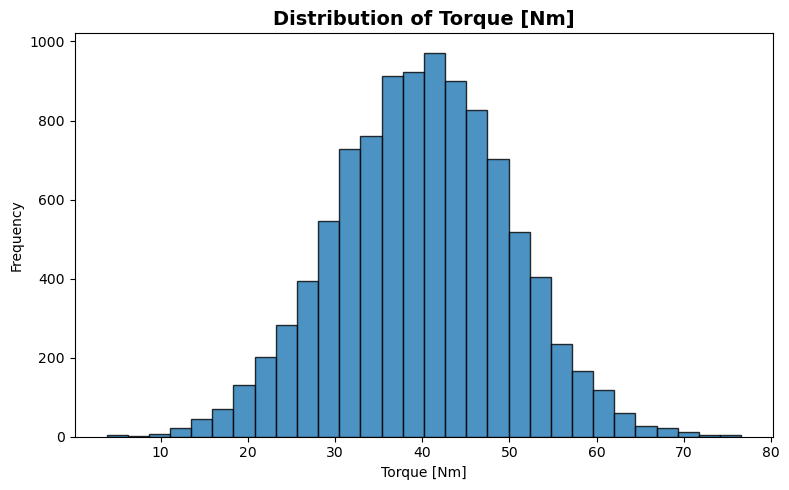

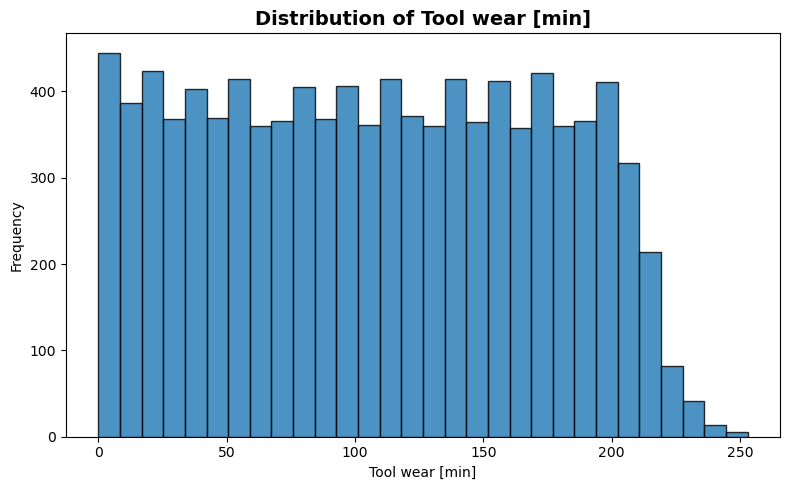

In [9]:
for feature in sensor_features:
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(
        df[feature],
        bins=30,
        edgecolor="black",
        alpha=0.8
    )

    ax.set_title(f"Distribution of {feature}", fontsize=14, fontweight="bold")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

## 5. Sensor Behaviour: Failed vs Non-Failed Machines

Sensor measurements are compared between failed and non-failed observations

Differences between the two groups may indicate variables that are useful for predicting machine failure

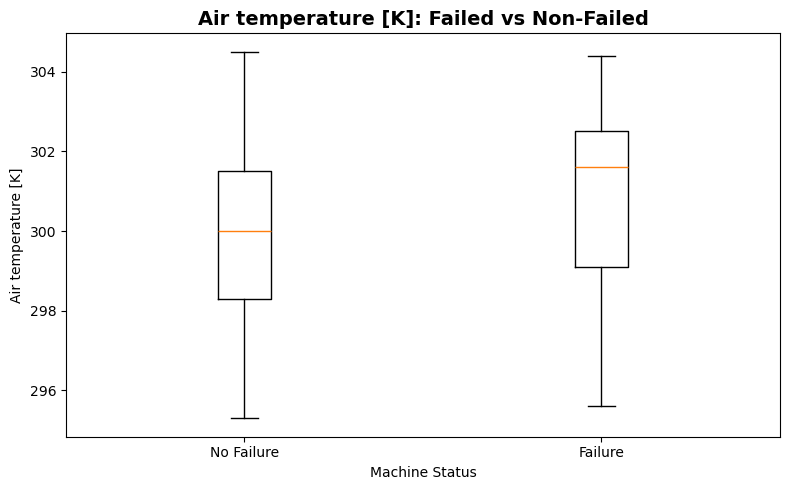

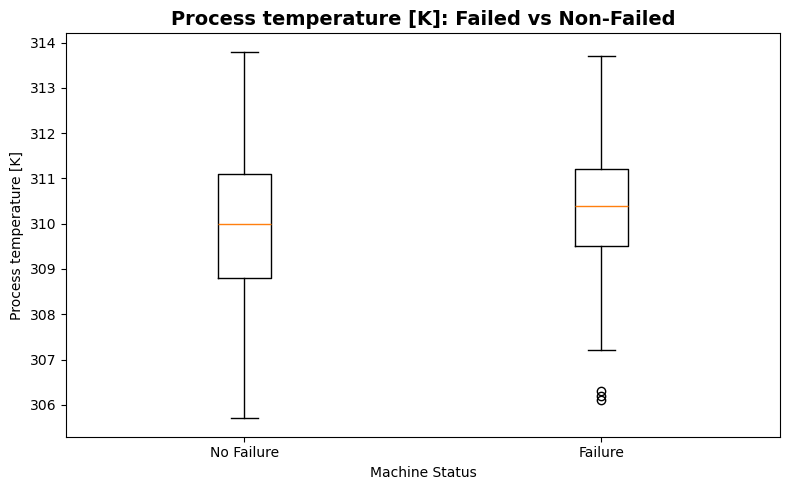

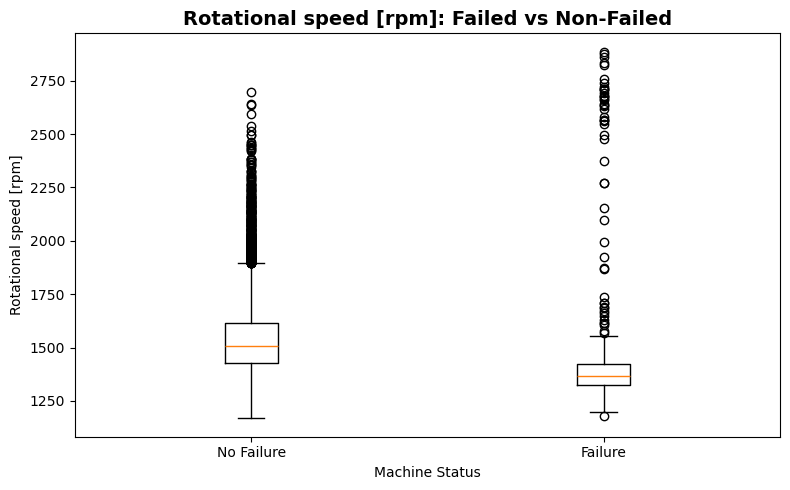

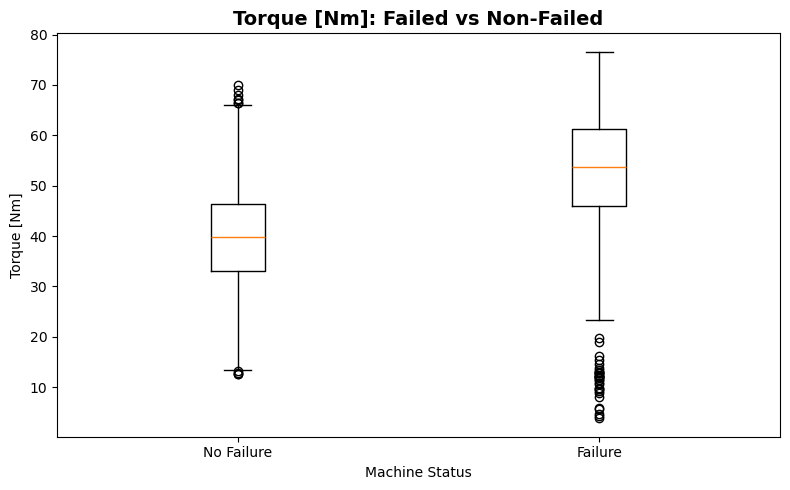

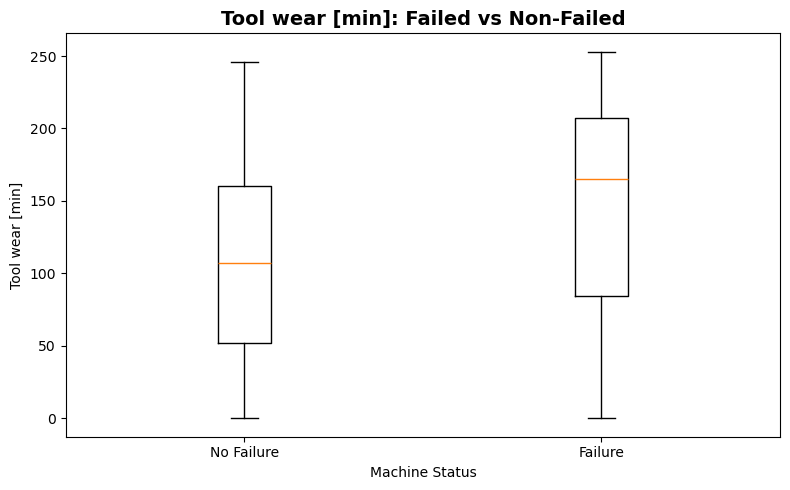

In [10]:
for feature in sensor_features:
    fig, ax = plt.subplots(figsize=(8, 5))

    healthy = df.loc[df[target] == 0, feature]
    failed = df.loc[df[target] == 1, feature]

    ax.boxplot(
        [healthy, failed],
        tick_labels=["No Failure", "Failure"]
    )

    ax.set_title(
        f"{feature}: Failed vs Non-Failed",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Machine Status")
    ax.set_ylabel(feature)

    plt.tight_layout()
    plt.show()

In [11]:
failure_sensor_comparison = (
    df.groupby(target)[sensor_features]
    .mean()
    .T
)

failure_sensor_comparison.columns = [
    "No Failure Mean",
    "Failure Mean"
]

failure_sensor_comparison["Difference"] = (
    failure_sensor_comparison["Failure Mean"]
    - failure_sensor_comparison["No Failure Mean"]
)

failure_sensor_comparison

,No Failure Mean,Failure Mean,Difference
Air temperature [K],299.973999,300.886431,0.912432
Process temperature [K],309.995570,310.290265,0.294696
Rotational speed [rpm],1540.260014,1496.486726,-43.773289
Torque [Nm],39.629655,50.168142,10.538486
Tool wear [min],106.693717,143.781711,37.087994


## 6. Correlation Analysis

Correlation analysis is used to examine linear relationships between numerical variables and identify variables that move together

Correlation does not imply causation, but it can reveal useful relationships and potential redundancy between features

In [12]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

correlation_matrix.round(2)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,1.00,0.12,0.32,-0.01,0.00,-0.01,-0.02,0.01,-0.02,-0.02,-0.00,-0.01
Air temperature [K],0.12,1.00,0.88,0.02,-0.01,0.01,0.08,0.01,0.14,0.00,0.00,0.02
Process temperature [K],0.32,0.88,1.00,0.02,-0.01,0.01,0.04,0.01,0.06,-0.00,0.00,0.02
Rotational speed [rpm],-0.01,0.02,0.02,1.00,-0.88,0.00,-0.04,0.01,-0.12,0.12,-0.10,-0.01
Torque [Nm],0.00,-0.01,-0.01,-0.88,1.00,-0.00,0.19,-0.01,0.14,0.08,0.18,0.02
Tool wear [min],-0.01,0.01,0.01,0.00,-0.00,1.00,0.11,0.12,-0.00,-0.01,0.16,0.01
Machine failure,-0.02,0.08,0.04,-0.04,0.19,0.11,1.00,0.36,0.58,0.52,0.53,0.00
TWF,0.01,0.01,0.01,0.01,-0.01,0.12,0.36,1.00,-0.01,0.01,0.04,0.03
HDF,-0.02,0.14,0.06,-0.12,0.14,-0.00,0.58,-0.01,1.00,0.02,0.05,-0.00
PWF,-0.02,0.00,-0.00,0.12,0.08,-0.01,0.52,0.01,0.02,1.00,0.12,-0.00


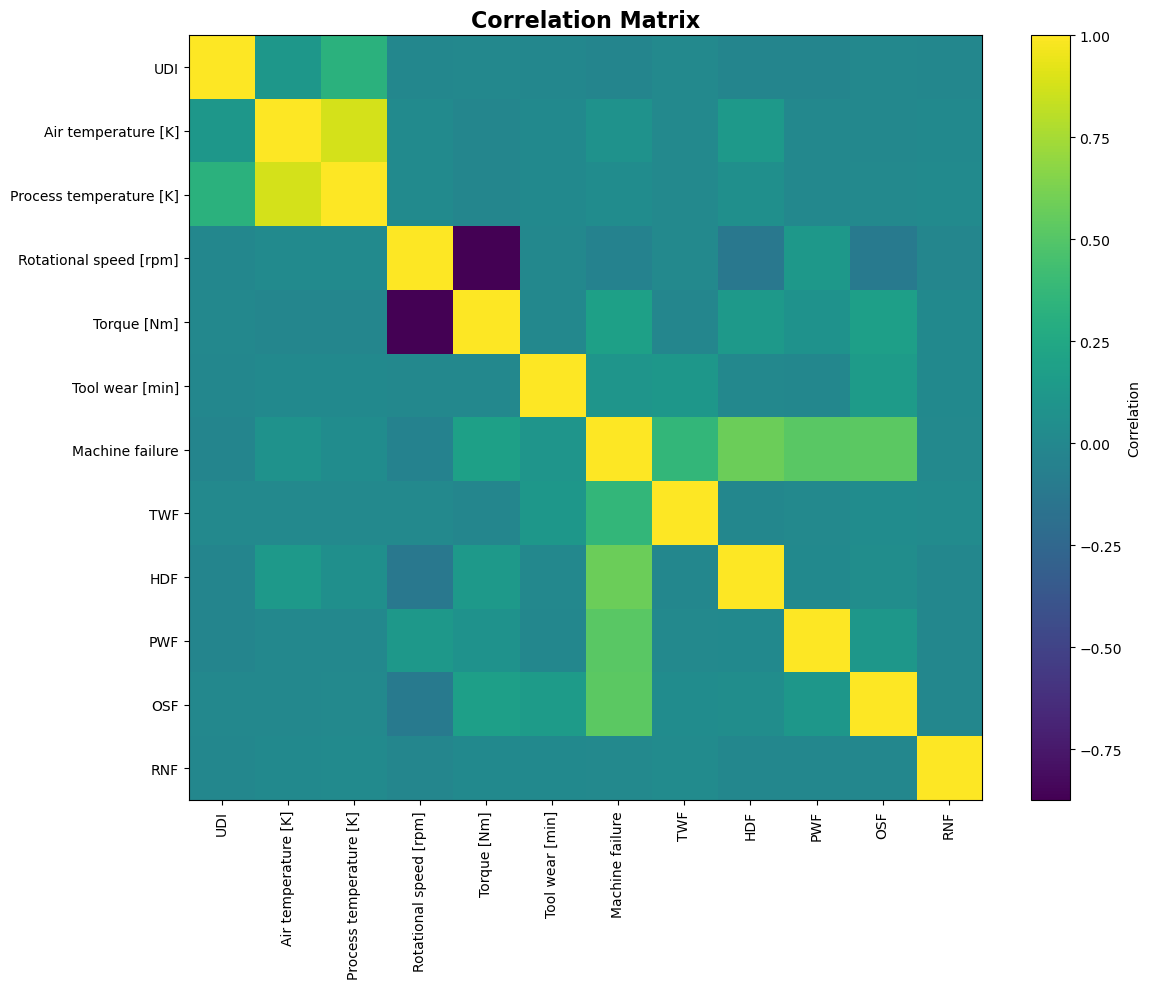

In [13]:
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(
    correlation_matrix,
    aspect="auto"
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=90
)

ax.set_yticklabels(
    correlation_matrix.columns
)

fig.colorbar(im, ax=ax, label="Correlation")

ax.set_title(
    "Correlation Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("../images/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Failure Mode Analysis

The dataset provides five indicators describing specific machine failure mechanisms

These are analysed to understand which failure modes occur most frequently

These variables describe failure outcomes and will not be used as predictive input features when training the final machine-failure model, as doing so would introduce target leakage

In [14]:
failure_mode_counts = df[failure_columns].sum().sort_values(ascending=False)

failure_mode_counts

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

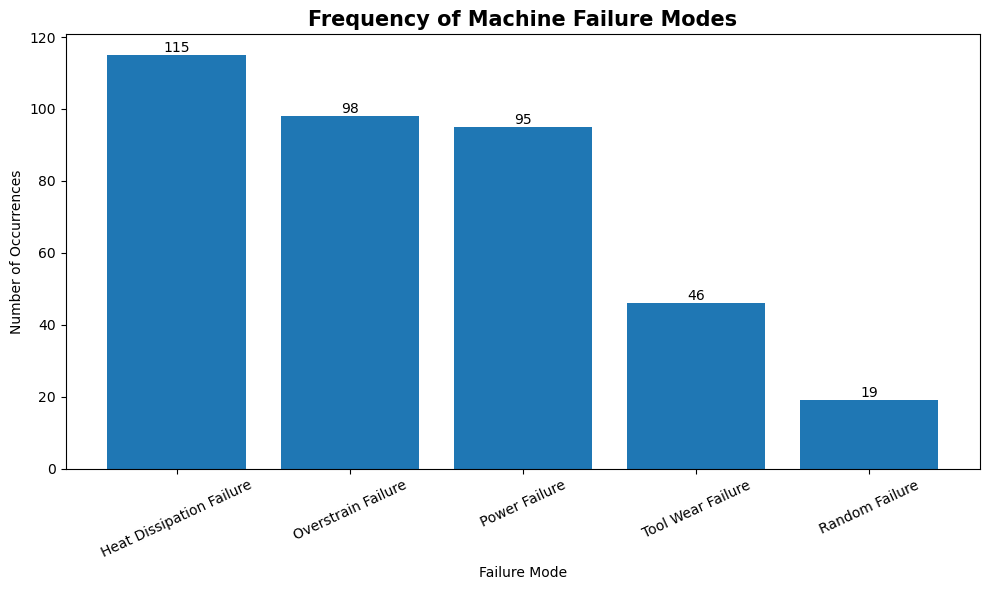

In [15]:
failure_names = {
    "TWF": "Tool Wear Failure",
    "HDF": "Heat Dissipation Failure",
    "PWF": "Power Failure",
    "OSF": "Overstrain Failure",
    "RNF": "Random Failure"
}

failure_mode_plot = failure_mode_counts.rename(index=failure_names)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    failure_mode_plot.index,
    failure_mode_plot.values
)

ax.set_title(
    "Frequency of Machine Failure Modes",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Failure Mode")
ax.set_ylabel("Number of Occurrences")

ax.tick_params(axis="x", rotation=25)

for bar, count in zip(bars, failure_mode_plot.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(count)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("../images/failure_mode_frequency.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Target Leakage Consideration

The variables `TWF`, `HDF`, `PWF`, `OSF`, and `RNF` represent specific failure outcomes rather than independent sensor measurements

Including these variables as predictors for `Machine failure` would provide the model with information directly related to the outcome being predicted

Therefore, these variables will be excluded from the predictive feature set during model development to avoid target leakage

The identifier variables `UDI` and `Product ID` will also be reviewed before modelling because identifiers generally do not represent meaningful machine operating conditions

# EDA Summary

The exploratory data analysis identified several important characteristics of the AI4I 2020 Predictive Maintenance dataset that will influence the modelling strategy

## Key Findings

### 1. Machine failures are highly imbalanced

Out of 10,000 observations:

- 9,661 observations represent normal operation
- 339 observations represent machine failure
- Only 3.39% of observations correspond to failures

This creates a substantial class imbalance. A model could achieve high accuracy by predicting the majority "No Failure" class while still failing to identify actual machine failures

Therefore, accuracy alone will not be sufficient for evaluating predictive performance

### 2. Product types have different failure rates

The dataset contains:

- 6,000 Low-quality (L) products
- 2,997 Medium-quality (M) products
- 1,003 High-quality (H) products

The observed failure rates were:

- L: 3.92%
- M: 2.77%
- H: 2.09%

Low-quality products therefore showed the highest observed machine failure rate in this dataset, while high-quality products showed the lowest

This suggests that product type may contain useful predictive information

### 3. Failure modes occur at different frequencies

The individual failure mechanisms occurred with the following frequencies:

- Heat Dissipation Failure (HDF): 115
- Overstrain Failure (OSF): 98
- Power Failure (PWF): 95
- Tool Wear Failure (TWF): 46
- Random Failure (RNF): 19

Heat Dissipation Failure was the most frequently recorded failure mode, while Random Failure was the least frequent

These variables describe specific failure outcomes and will therefore be excluded from the predictors used to predict overall `Machine failure` in order to avoid target leakage

### 4. Operational variables show important relationships

The correlation analysis revealed relationships between several operating variables

In particular:

- Air temperature and process temperature show a strong positive relationship
- Rotational speed and torque show a strong negative relationship
- Machine failure shows relationships with several operating measurements and specific failure mechanisms

These relationships suggest that machine operating conditions may provide useful information for predicting failure

### 5. Identifier variables should not be treated as machine conditions

`UDI` and `Product ID` identify observations/products rather than directly measuring machine operating behaviour

They will therefore not be used as predictive operating features in the machine-learning models

## Modelling Implications

The EDA suggests that the modelling stage should:

1. Remove identifier variables that do not represent operating conditions
2. Exclude failure-mode variables that would introduce target leakage
3. Encode the categorical `Type` feature for machine-learning models
4. Account for the strong class imbalance in the target variable
5. Compare multiple classification models rather than relying on a single algorithm
6. Evaluate models using precision, recall, F1-score, ROC-AUC and confusion matrices in addition to accuracy

For predictive maintenance, correctly identifying machines at risk of failure is particularly important. The next stage will therefore prepare the dataset and engineer suitable features before model training